# **Task 1: Exploring and Visualizing the Iris Dataset**

**Intern:** : Hafsa Atif

**Internship:** DevelopersHub Corporation — AI/ML Engineering Internship

**Objective:** Load the Iris dataset, inspect its structure, and run a
proper EDA pass (summary stats, distributions, correlations, and
species comparisons) before visualizing relationships between features.
Dataset loads directly from seaborn — no download needed.

## **Import Libraries**

In [1]:
# import pandas for working with tabular data
import pandas as pd
# import numpy for numeric operations
import numpy as np
# import matplotlib for plotting
import matplotlib.pyplot as plt
# import seaborn for nicer statistical charts + it ships the iris dataset
import seaborn as sns

# use a clean grid style for all charts in this notebook
sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


**Load the Dataset**

In [2]:
# load the iris dataset straight from seaborn (no CSV needed)
df = sns.load_dataset('iris')

# show the first 5 rows to confirm it loaded correctly
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# **DETAILED EDA**

**Check Shape, Columns & Data Types**

In [3]:
# print number of rows and columns
print('Shape:', df.shape)
# print the column names
print('Columns:', df.columns.tolist())
# print data type + non-null count for every column
df.info()

Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Check Missing Values**

In [4]:
# check if any column has missing values
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


**Statistical Summary (describe)**

In [5]:
# get min, max, mean, std, quartiles for every numeric column
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Count Samples per Species (value_counts)**

In [6]:
# count how many flowers belong to each species
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


# **Visualize Species Count — Bar Chart**

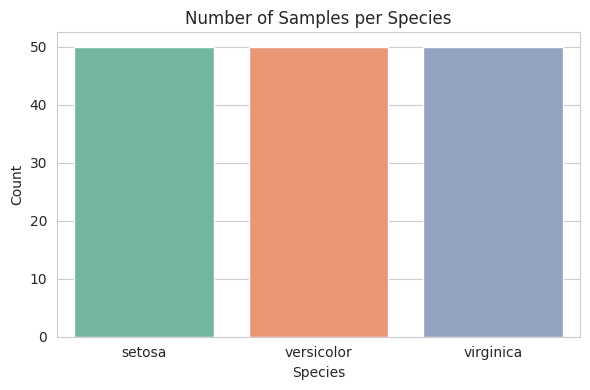

In [7]:
plt.figure(figsize=(6, 4))

# bar chart version of the value_counts above, easier to read at a glance
sns.countplot(data=df, x='species', hue='species', palette='Set2', legend=False)

plt.title('Number of Samples per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

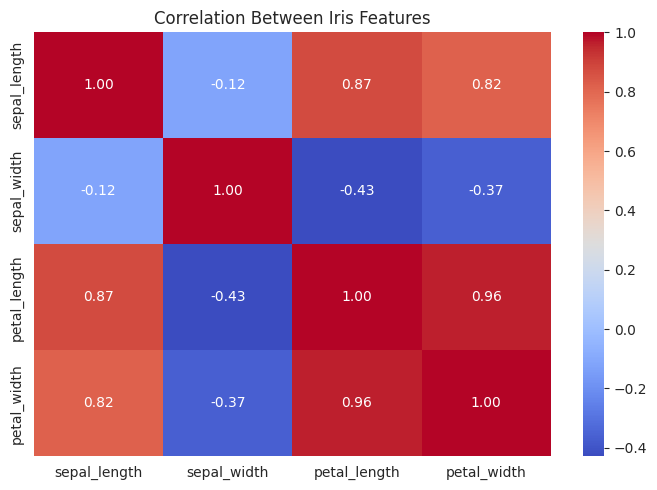

In [8]:
plt.figure(figsize=(7, 5))

# correlation matrix between the 4 numeric measurements
corr = df.drop('species', axis=1).corr()

# heatmap of correlations, annotated with the actual numbers
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Between Iris Features')
plt.tight_layout()
plt.show()

# **Pairplot :  All Feature Relationships**

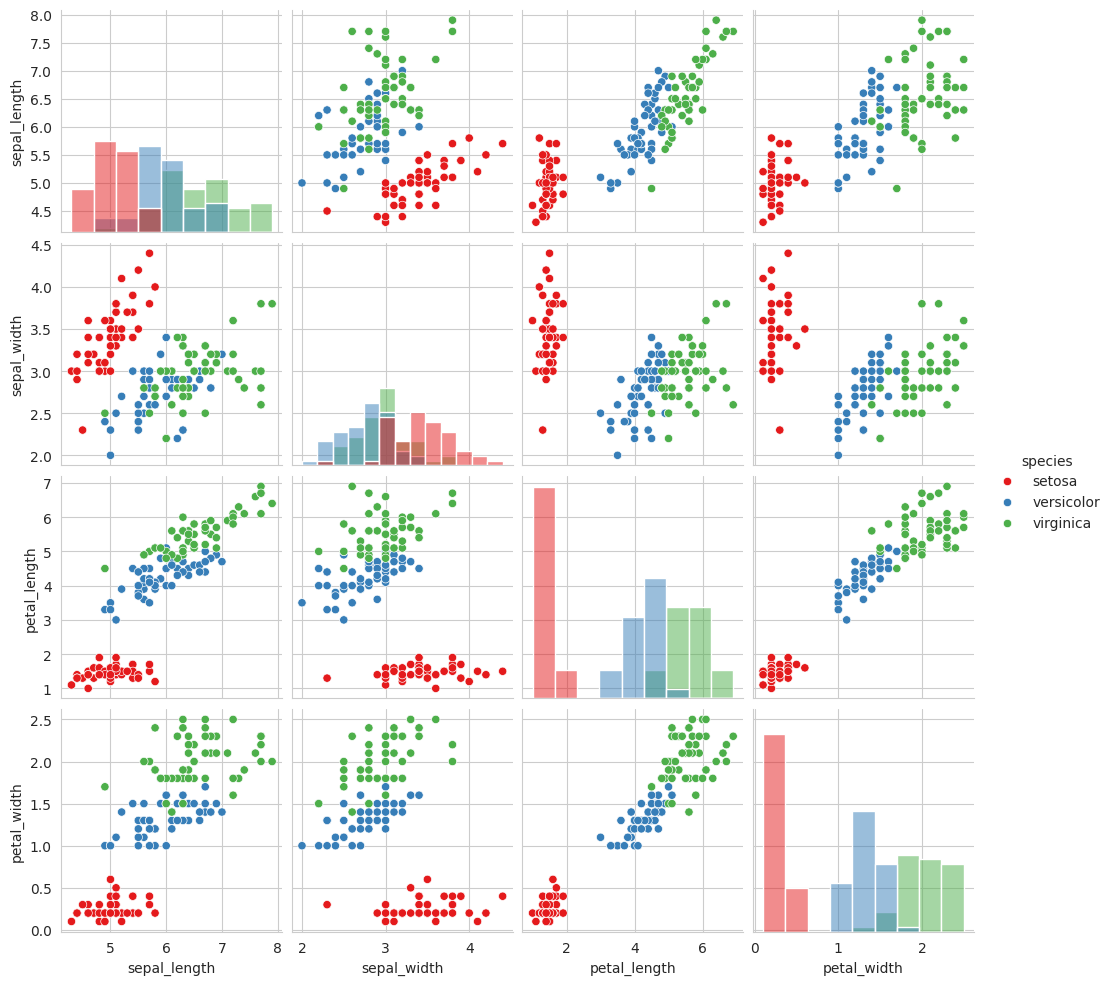

In [9]:
# pairwise scatter plots for every feature combination, colored by species
# this is the single most useful EDA chart for this dataset
sns.pairplot(df, hue='species', palette='Set1', diag_kind='hist')
plt.show()

# **Scatter Plot : Sepal Length vs Sepal Width**

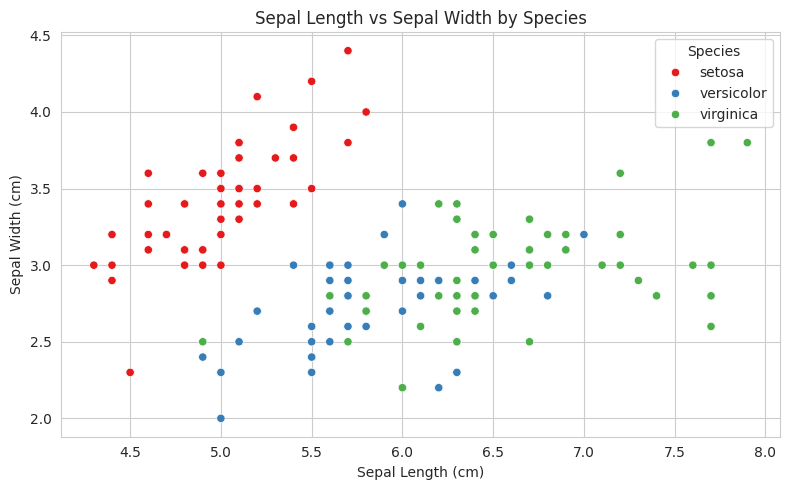

In [10]:
plt.figure(figsize=(8, 5))

# scatter plot: sepal length on x, sepal width on y, colored by species
sns.scatterplot(
    data=df,
    x='sepal_length',     # x-axis column
    y='sepal_width',      # y-axis column
    hue='species',        # color points by species
    palette='Set1'        # color palette to use
)

# add chart title and axis labels
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')

# tighten layout so labels don't get cut off, then render
plt.tight_layout()
plt.show()

# **Histograms — Feature Distributions**

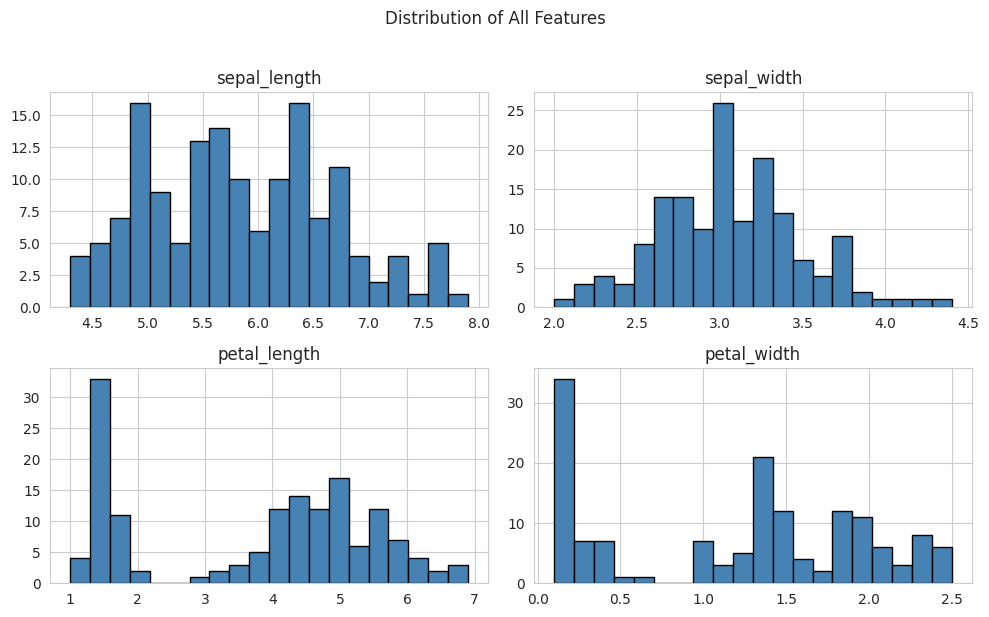

In [11]:
# drop the species column (non-numeric) and plot a histogram per feature
df.drop('species', axis=1).hist(
    bins=20,             # number of bars per histogram
    figsize=(10, 6),     # overall figure size
    color='steelblue',   # bar color
    edgecolor='black'    # bar border color
)

# add an overall title above all 4 subplots
plt.suptitle('Distribution of All Features', y=1.02)
plt.tight_layout()
plt.show()

# **Box Plots : Feature Spread by Species**

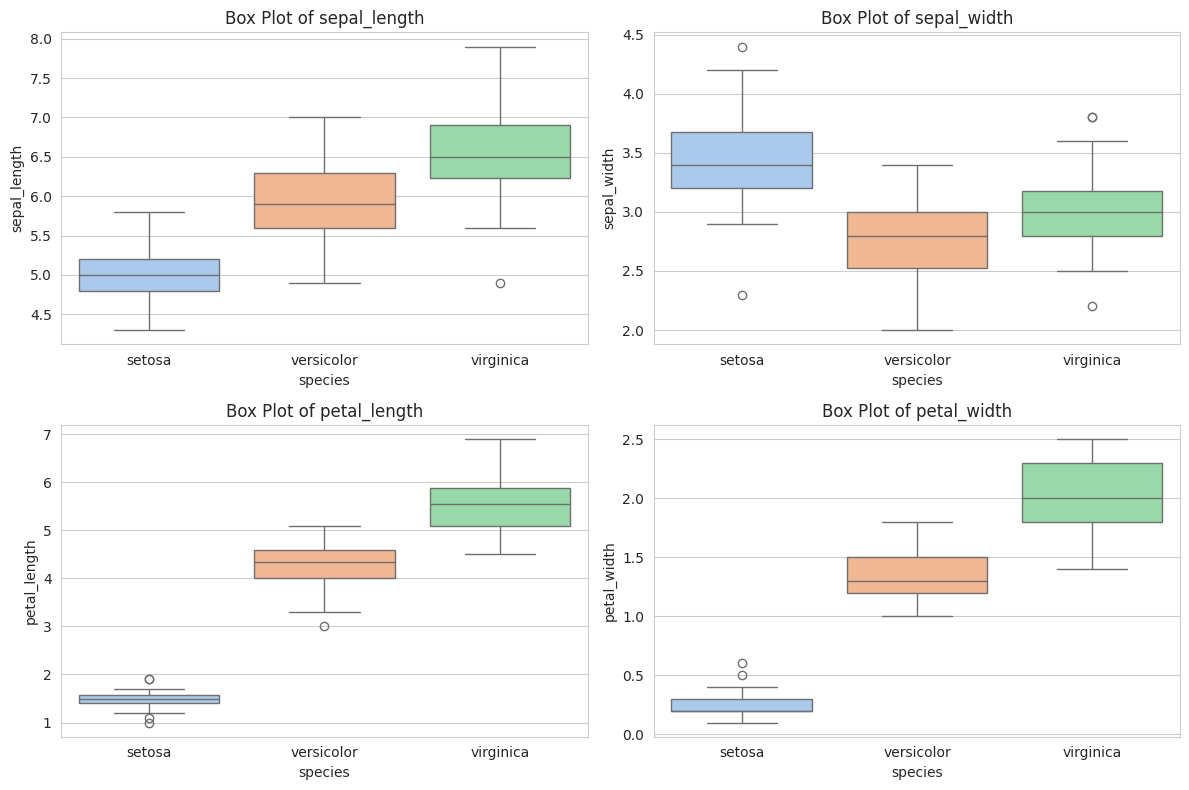

In [12]:
# create a 2x2 grid of subplots, one box plot per feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# list of the 4 numeric features to plot
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# loop through each feature and draw it in its own subplot
for i, feature in enumerate(features):
    ax = axes[i // 2, i % 2]                                     # pick the right grid cell
    sns.boxplot(data=df, x='species', y=feature, hue='species', palette='pastel', ax=ax, legend=False)  # draw box plot
    ax.set_title(f'Box Plot of {feature}')                       # title for this subplot

plt.tight_layout()
plt.show()

# **Summary & Insights**



- **Dataset:** 150 rows, 5 columns, no missing values, perfectly balanced
  (50 samples per species).
- **Correlation:** Petal length and petal width are very strongly
  correlated (~0.96) — they grow together. Sepal width is the odd one out,
  with weak/negative correlation to the other three features.
- **Pairplot:** Confirms that petal length and petal width are the cleanest
  features for telling species apart — setosa separates almost perfectly
  on these two axes alone.
- **Scatter plot:** Setosa forms a tight, clearly separated cluster on
  sepal measurements too — small petals and wide sepals make it visually
  distinct. Versicolor and virginica overlap more, with virginica generally
  sitting toward larger sepal values.
- **Histograms:** Petal length and petal width are clearly bimodal — a
  small low-value cluster (setosa) sits apart from a wider spread of higher
  values (versicolor + virginica). Sepal measurements are more evenly
  spread, reinforcing that petals are the stronger species predictor.
- **Box plots:** Setosa's petal length/width boxes sit far below the other
  two species with almost no overlap, confirming the scatter/pairplot
  findings. A few mild outliers appear in sepal_width, but nothing extreme.
- **Overall conclusion:** Setosa is easily separable from the other two
  species using petal measurements alone; versicolor and virginica are
  more similar to each other and would need more features (or a model) to
  separate reliably.